In [1]:
# ============================
# IMPORT LIBRARIES
# ============================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import shap

import joblib

import warnings

warnings.filterwarnings("ignore")

In [2]:
# ============================
# LOAD DATASET
# ============================

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ============================
# DATASET SHAPE
# ============================

df.shape

(7043, 21)

In [4]:
# ============================
# DATASET INFORMATION
# ============================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# ============================
# CHECK MISSING VALUES
# ============================

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# ============================
# TARGET VARIABLE DISTRIBUTION
# ============================

df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

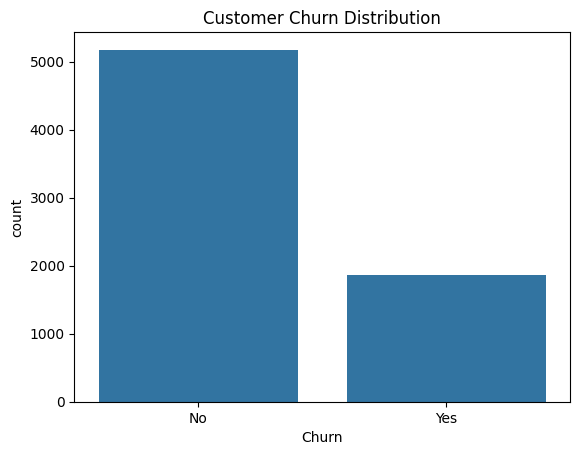

In [7]:
# ============================
# VISUALIZE CHURN DISTRIBUTION
# ============================

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [8]:
# ============================
# CHECK TARGET VARIABLE PERCENTAGE
# ============================

df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [9]:
# ============================
# STATISTICAL SUMMARY
# ============================

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


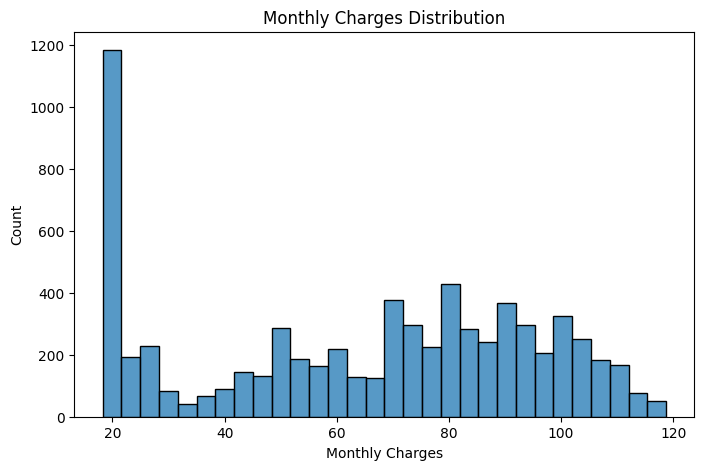

In [10]:
# ============================
# MONTHLY CHARGES DISTRIBUTION
# ============================

plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30)

plt.title("Monthly Charges Distribution")

plt.xlabel("Monthly Charges")

plt.ylabel("Count")

plt.show()

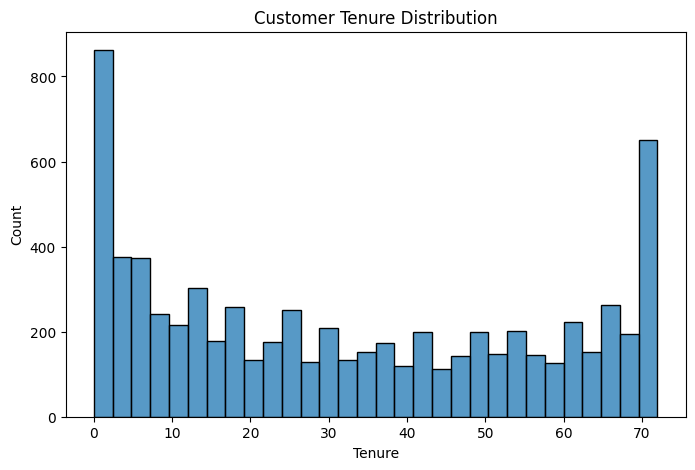

In [11]:
# ============================
# TENURE DISTRIBUTION
# ============================

plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], bins=30)

plt.title("Customer Tenure Distribution")

plt.xlabel("Tenure")

plt.ylabel("Count")

plt.show()

In [12]:
# ============================
# CONVERT TOTALCHARGES TO NUMERIC
# ============================

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [13]:
# ============================
# CHECK MISSING VALUES AGAIN
# ============================

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
# ============================
# REMOVE MISSING VALUES
# ============================

df.dropna(inplace=True)

In [15]:
# ============================
# DROP CUSTOMER ID COLUMN
# ============================

df.drop('customerID', axis=1, inplace=True)

In [16]:
# ============================
# FINAL DATASET INFORMATION
# ============================

df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [17]:
# ============================
# FINAL DATASET PREVIEW
# ============================

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# ============================
# FEATURE ENGINEERING
# CREATE TENURE BANDS
# ============================

def tenure_band(tenure):
    
    if tenure <= 12:
        return "0-1 Year"
    
    elif tenure <= 24:
        return "1-2 Years"
    
    elif tenure <= 48:
        return "2-4 Years"
    
    else:
        return "4+ Years"


df['tenure_band'] = df['tenure'].apply(tenure_band)

In [19]:
# ============================
# CREATE CHARGES PER TENURE FEATURE
# ============================

df['charges_per_tenure'] = (
    df['TotalCharges'] / (df['tenure'] + 1)
)

In [20]:
# ============================
# CREATE TOTAL SERVICES FEATURE
# ============================

services = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['total_services'] = (
    df[services] == 'Yes'
).sum(axis=1)

In [21]:
# ============================
# CHECK NEW FEATURES
# ============================

df[
    [
        'tenure_band',
        'charges_per_tenure',
        'total_services'
    ]
].head()

,tenure_band,charges_per_tenure,total_services
0,0-1 Year,14.925000,1
1,2-4 Years,53.985714,3
2,0-1 Year,36.050000,3
3,2-4 Years,40.016304,3
4,0-1 Year,50.550000,1


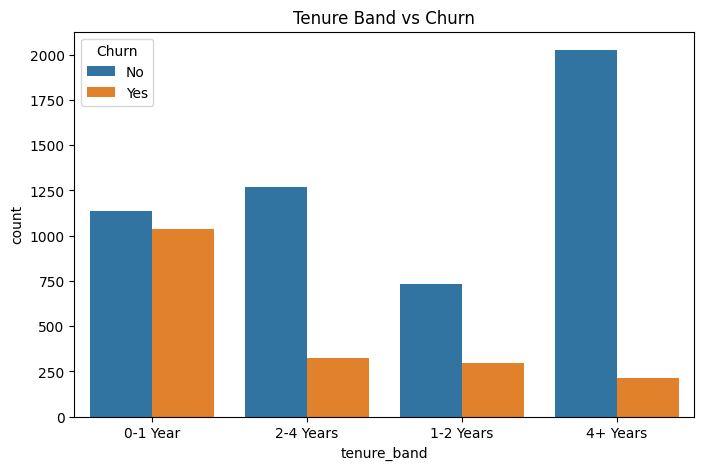

In [22]:
# ============================
# VISUALIZE TENURE BAND VS CHURN
# ============================

plt.figure(figsize=(8,5))

sns.countplot(
    x='tenure_band',
    hue='Churn',
    data=df
)

plt.title("Tenure Band vs Churn")

plt.show()

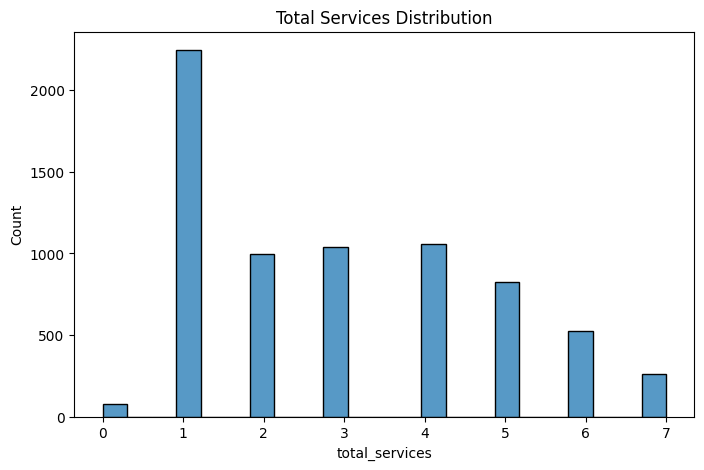

In [23]:
# ============================
# VISUALIZE TOTAL SERVICES
# ============================

plt.figure(figsize=(8,5))

sns.histplot(df['total_services'])

plt.title("Total Services Distribution")

plt.show()

In [24]:
# ============================
# SEPARATE FEATURES & TARGET
# ============================

X = df.drop('Churn', axis=1)

y = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [26]:
# ============================
# CHECK TARGET VARIABLE
# ============================

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [27]:
# ============================
# APPLY ONE HOT ENCODING
# ============================

X = pd.get_dummies(
    X,
    drop_first=True
)

In [28]:
# ============================
# CHECK ENCODED FEATURES
# ============================

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,charges_per_tenure,total_services,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_band_1-2 Years,tenure_band_2-4 Years,tenure_band_4+ Years
0,0,1,29.85,29.85,14.925000,1,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,53.985714,3,True,False,False,True,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,36.050000,3,True,False,False,True,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,40.016304,3,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,50.550000,1,False,False,False,True,...,False,False,False,True,False,True,False,False,False,False


In [29]:
# ============================
# CHECK FINAL DATASET SHAPE
# ============================

X.shape

(7032, 35)

In [30]:
# ============================
# VERIFY NO CATEGORICAL COLUMNS
# ============================

X.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
charges_per_tenure                       float64
total_services                             int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No inter

In [31]:
# ============================
# TRAIN TEST SPLIT
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
# ============================
# CHECK TRAIN TEST SHAPES
# ============================

print("X_train Shape :", X_train.shape)

print("X_test Shape :", X_test.shape)

print("y_train Shape :", y_train.shape)

print("y_test Shape :", y_test.shape)

X_train Shape : (5625, 35)
X_test Shape : (1407, 35)
y_train Shape : (5625,)
y_test Shape : (1407,)


In [33]:
# ============================
# LOGISTIC REGRESSION PIPELINE
# ============================

log_pipeline = Pipeline([
    
    ('scaler', StandardScaler()),
    
    ('model', LogisticRegression())
])

In [34]:
# ============================
# RANDOM FOREST MODEL
# ============================

rf_model = RandomForestClassifier(
    random_state=42
)

In [35]:
# ============================
# XGBOOST MODEL
# ============================

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

In [36]:
# ============================
# TRAIN LOGISTIC REGRESSION
# ============================

log_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [37]:
# ============================
# TRAIN RANDOM FOREST
# ============================

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
# ============================
# TRAIN XGBOOST MODEL
# ============================

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [39]:
# ============================
# MAKE PREDICTIONS
# ============================

log_preds = log_pipeline.predict(X_test)

rf_preds = rf_model.predict(X_test)

xgb_preds = xgb_model.predict(X_test)

In [40]:
# ============================
# MODEL ACCURACY SCORES
# ============================

print("Logistic Regression Accuracy :",
      accuracy_score(y_test, log_preds))

print("Random Forest Accuracy :",
      accuracy_score(y_test, rf_preds))

print("XGBoost Accuracy :",
      accuracy_score(y_test, xgb_preds))

Logistic Regression Accuracy : 0.7945984363894811
Random Forest Accuracy : 0.7910447761194029
XGBoost Accuracy : 0.7697228144989339


In [41]:
# ============================
# MODEL F1 SCORES
# ============================

print("Logistic Regression F1 Score :",
      f1_score(y_test, log_preds))

print("Random Forest F1 Score :",
      f1_score(y_test, rf_preds))

print("XGBoost F1 Score :",
      f1_score(y_test, xgb_preds))

Logistic Regression F1 Score : 0.5793304221251819
Random Forest F1 Score : 0.5598802395209581
XGBoost F1 Score : 0.543661971830986


In [42]:
# ============================
# CLASSIFICATION REPORTS
# ============================

print("Logistic Regression Report\n")

print(classification_report(
    y_test,
    log_preds
))

Logistic Regression Report

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



In [43]:
print("Random Forest Report\n")

print(classification_report(
    y_test,
    rf_preds
))

Random Forest Report

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [44]:
print("XGBoost Report\n")

print(classification_report(
    y_test,
    xgb_preds
))

XGBoost Report

              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.57      0.52      0.54       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



In [45]:
# ============================
# ROC AUC SCORES
# ============================

log_auc = roc_auc_score(y_test, log_preds)

rf_auc = roc_auc_score(y_test, rf_preds)

xgb_auc = roc_auc_score(y_test, xgb_preds)

print("Logistic Regression ROC-AUC :", log_auc)

print("Random Forest ROC-AUC :", rf_auc)

print("XGBoost ROC-AUC :", xgb_auc)

Logistic Regression ROC-AUC : 0.7108636907196215
Random Forest ROC-AUC : 0.6982090997095837
XGBoost ROC-AUC : 0.6888055142852706


In [46]:
# ============================
# MODEL COMPARISON TABLE
# ============================

results = pd.DataFrame({
    
    'Model' : [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    
    'Accuracy' : [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    
    'F1 Score' : [
        f1_score(y_test, log_preds),
        f1_score(y_test, rf_preds),
        f1_score(y_test, xgb_preds)
    ],
    
    'ROC-AUC' : [
        log_auc,
        rf_auc,
        xgb_auc
    ]
})

results

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.794598,0.579330,0.710864
1,Random Forest,0.791045,0.559880,0.698209
2,XGBoost,0.769723,0.543662,0.688806


In [47]:
# ============================
# BEST MODEL SELECTION
# ============================

best_model = rf_model

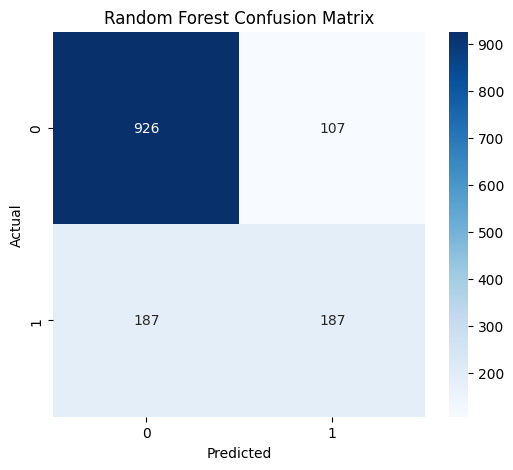

In [48]:
# ============================
# CONFUSION MATRIX
# ============================

cm = confusion_matrix(
    y_test,
    rf_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

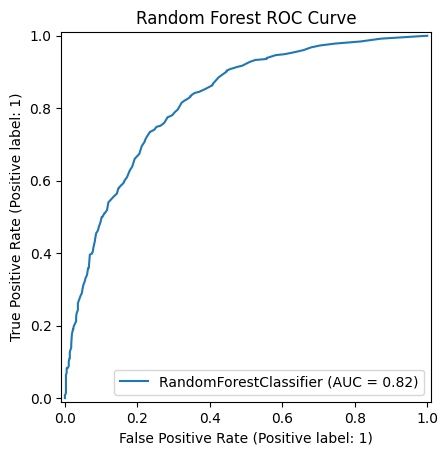

In [49]:
# ============================
# ROC CURVE
# ============================

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest ROC Curve")

plt.show()

In [50]:
# ============================
# FEATURE IMPORTANCE
# ============================

feature_importance = pd.DataFrame({
    
    'Feature' : X.columns,
    
    'Importance' : rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.140939
1,tenure,0.136192
2,MonthlyCharges,0.127460
4,charges_per_tenure,0.126513
12,InternetService_Fiber optic,0.035086
30,PaymentMethod_Electronic check,0.034473
5,total_services,0.033416
27,Contract_Two year,0.026386
6,gender_Male,0.024377
28,PaperlessBilling_Yes,0.022795


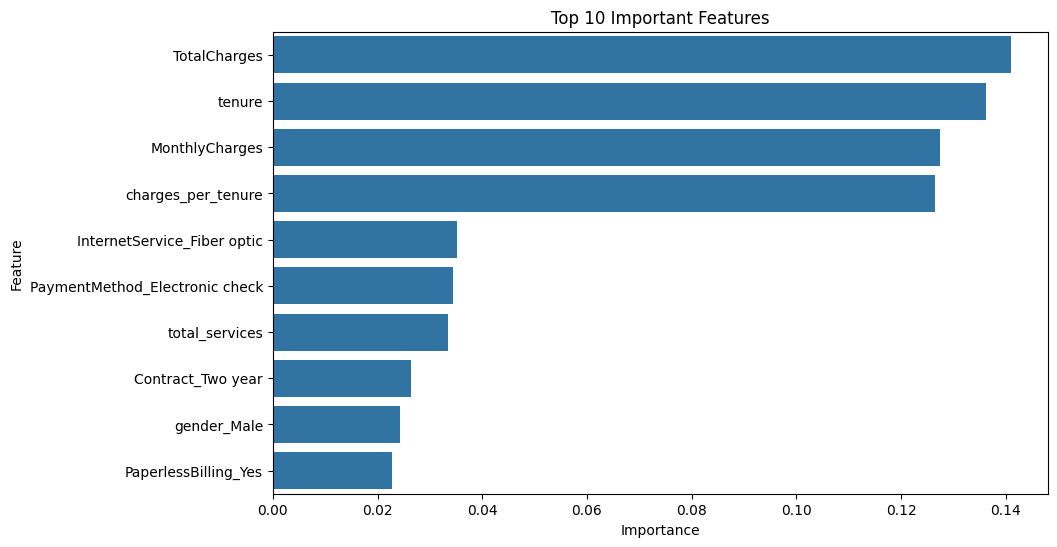

In [51]:
# ============================
# TOP 10 IMPORTANT FEATURES
# ============================

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()

In [52]:
# ============================
# THRESHOLD OPTIMIZATION
# ============================

rf_probs = rf_model.predict_proba(X_test)[:,1]

In [53]:
# ============================
# FIND BEST THRESHOLD
# ============================

thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0

best_f1 = 0

In [54]:
for threshold in thresholds:
    
    preds = (rf_probs >= threshold).astype(int)
    
    score = f1_score(y_test, preds)
    
    if score > best_f1:
        
        best_f1 = score
        
        best_threshold = threshold

In [55]:
# ============================
# BEST THRESHOLD RESULTS
# ============================

print("Best Threshold :", best_threshold)

print("Best F1 Score :", best_f1)

Best Threshold : 0.30000000000000004
Best F1 Score : 0.6120218579234973


In [56]:
# ============================
# FINAL PREDICTIONS USING
# OPTIMIZED THRESHOLD
# ============================

optimized_preds = (
    rf_probs >= best_threshold
).astype(int)

In [57]:
# ============================
# OPTIMIZED MODEL REPORT
# ============================

print(classification_report(
    y_test,
    optimized_preds
))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1033
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



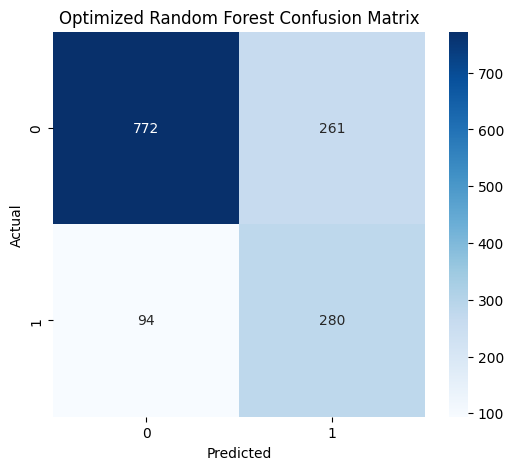

In [58]:
# ============================
# OPTIMIZED CONFUSION MATRIX
# ============================

cm = confusion_matrix(
    y_test,
    optimized_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Optimized Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [61]:
# ============================
# SHAP EXPLAINABILITY
# ============================
explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(X_test)

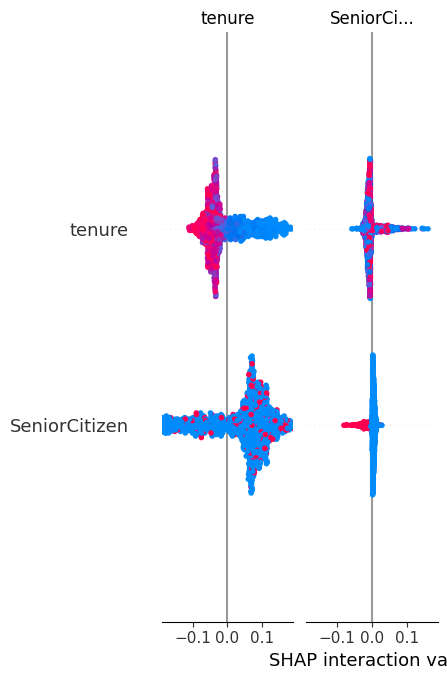

In [62]:
# ============================
# SHAP SUMMARY PLOT
# ============================

shap.summary_plot(
    shap_values,
    X_test
)

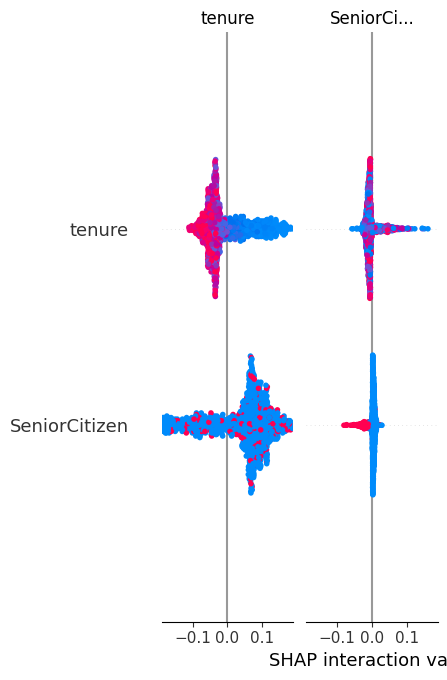

In [63]:
# ============================
# SHAP BAR PLOT
# ============================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

In [65]:
# ============================
# TOP FEATURES BASED ON SHAP
# ============================

shap_importance = np.abs(
    shap_values
).mean(axis=0)

# Handle multi-dimensional SHAP output
if len(shap_importance.shape) > 1:
    
    shap_importance = shap_importance[:,1]

shap_df = pd.DataFrame({
    
    'Feature' : X.columns,
    
    'Importance' : shap_importance
})

shap_df = shap_df.sort_values(
    by='Importance',
    ascending=False
)

shap_df.head(10)

,Feature,Importance
1,tenure,0.056794
12,InternetService_Fiber optic,0.045001
27,Contract_Two year,0.036138
3,TotalCharges,0.029681
30,PaymentMethod_Electronic check,0.027927
26,Contract_One year,0.021974
2,MonthlyCharges,0.021909
34,tenure_band_4+ Years,0.020406
15,OnlineSecurity_Yes,0.015708
21,TechSupport_Yes,0.014942


In [67]:
# ============================
# BUSINESS INSIGHTS
# CONTRACT VS CHURN
# ============================

contract_churn = (
    
    df.groupby('Contract')['Churn']
    
    .value_counts(normalize=True)
    
    .unstack()
    
    * 100
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


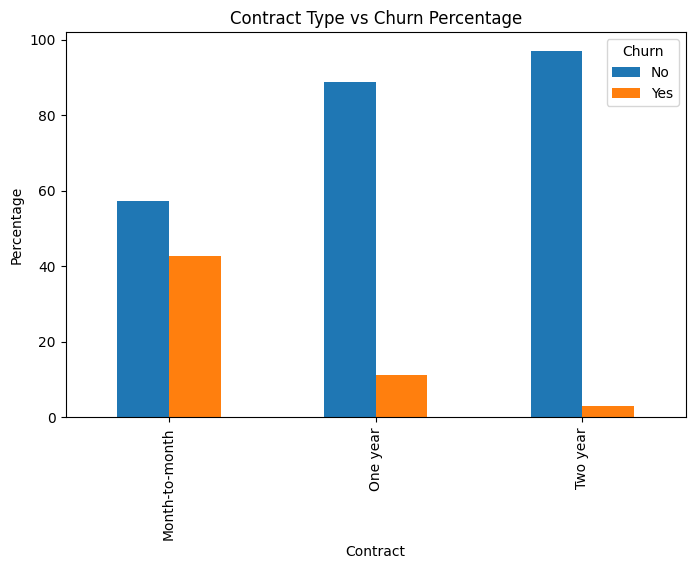

In [68]:
# ============================
# VISUALIZE CONTRACT VS CHURN
# ============================

contract_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Contract Type vs Churn Percentage")

plt.ylabel("Percentage")

plt.show()

In [69]:
# ============================
# HIGH MONTHLY CHARGES ANALYSIS
# ============================

high_charge = df[
    df['MonthlyCharges'] > 70
]

high_charge['Churn'].value_counts(
    normalize=True
) * 100

Churn
No     64.618822
Yes    35.381178
Name: proportion, dtype: float64

In [70]:
# ============================
# TENURE BAND VS CHURN
# ============================

tenure_churn = (
    
    df.groupby('tenure_band')['Churn']
    
    .value_counts(normalize=True)
    
    .unstack()
    
    * 100
)

tenure_churn

Churn,No,Yes
tenure_band,,
0-1 Year,52.321839,47.678161
1-2 Years,71.289062,28.710938
2-4 Years,79.611041,20.388959
4+ Years,90.486824,9.513176


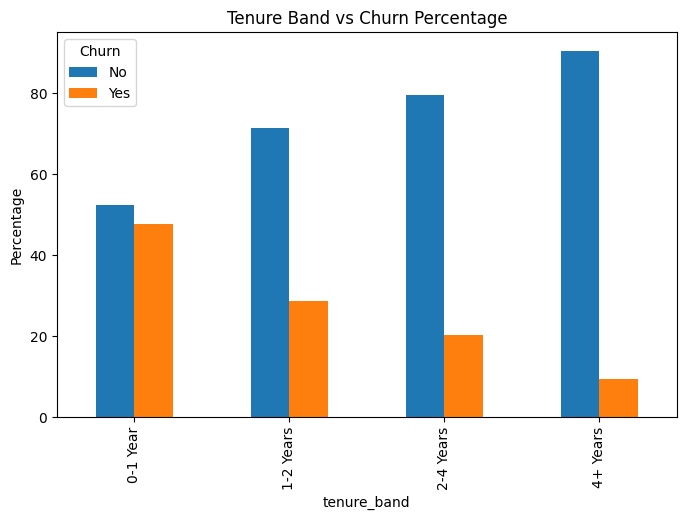

In [71]:
# ============================
# VISUALIZE TENURE BAND VS CHURN
# ============================

tenure_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Tenure Band vs Churn Percentage")

plt.ylabel("Percentage")

plt.show()

In [72]:
# ============================
# MODEL SAVING
# ============================

joblib.dump(
    rf_model,
    "../models/best_churn_model.pkl"
)

['../models/best_churn_model.pkl']

In [73]:
# ============================
# LOAD SAVED MODEL
# ============================

loaded_model = joblib.load(
    "../models/best_churn_model.pkl"
)

In [74]:
# ============================
# TEST SAVED MODEL
# ============================

loaded_model.predict(X_test[:5])

array([0, 1, 0, 0, 0])

# Conclusion

This project focused on predicting customer churn using machine learning techniques on the IBM Telco Customer Churn dataset.

The workflow included:
- Data Cleaning
- Feature Engineering
- One Hot Encoding
- Machine Learning Pipelines
- Threshold Optimization
- SHAP Explainability
- Feature Importance Analysis

Among all models, Random Forest performed best based on F1 Score and ROC-AUC.

Key business insights identified:
- Month-to-month customers showed higher churn rates
- Customers with high monthly charges were more likely to churn
- Long-term customers had significantly lower churn probability

This project demonstrates the use of machine learning for customer retention and business decision-making.